# Arbol de decisioens

### Librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import math
from collections import Counter

### Procesamiento de datos

In [3]:
# Cargar dataset
df = pd.read_csv('../pwlds_full.csv')
df['Password'] = df['Password'].astype(str).fillna('')

def compute_entropy(pw):
    if not pw:
        return 0
    counts = Counter(pw)
    length = len(pw)
    entropy = -sum((count / length) * math.log2(count / length) for count in counts.values())
    return entropy

def extract_features(pw):
    length = len(pw)
    num_digits = sum(c.isdigit() for c in pw)
    num_lowercase = sum(c.islower() for c in pw)
    num_uppercase = sum(c.isupper() for c in pw)
    num_special_chars = sum(not c.isalnum() for c in pw)

    char_count = {}
    max_consecutive_chars = 1
    current_streak = 1
    char_type_changes = 0
    prev_type = None

    for i, c in enumerate(pw):
        # Caracter repetido
        char_count[c] = char_count.get(c, 0) + 1

        # Consecutivos
        if i > 0 and pw[i] == pw[i - 1]:
            current_streak += 1
            max_consecutive_chars = max(max_consecutive_chars, current_streak)
        else:
            current_streak = 1

        # Tipo de carácter
        if c.isdigit():
            t = 'digit'
        elif c.islower():
            t = 'lower'
        elif c.isupper():
            t = 'upper'
        else:
            t = 'special'

        if prev_type and t != prev_type:
            char_type_changes += 1
        prev_type = t

    char_repea = sum(count - 1 for count in char_count.values() if count > 1)
    entropy = compute_entropy(pw)

    return [
        length, num_digits, num_lowercase, num_uppercase, num_special_chars,
        char_repea, max_consecutive_chars, char_type_changes, entropy
    ]

### Extraer características y etiquetas

In [4]:
X = np.array([extract_features(pw) for pw in df['Password']])
y = df['Strength_Level'].astype(int)  # Convertir a rango 0–3

In [5]:
print(df['Strength_Level'].value_counts().sort_index())

Strength_Level
0    2000043
1    2000021
2    2000024
3    2000382
4    2000000
Name: count, dtype: int64


### Segmentación de datos

In [6]:
# Dividir en entrenamiento, validación y prueba
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)
print("Pruebas:", X_test.shape, y_test.shape)

Entrenamiento: (7000329, 9) (7000329,)
Validación: (1500070, 9) (1500070,)
Pruebas: (1500071, 9) (1500071,)


### Entrenar el arbol

In [7]:
dt_model = DecisionTreeClassifier(
    criterion='gini', 
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42
)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### Evaluar el modelo (conjunto de prueba)

In [8]:
y_pred_dt = dt_model.predict(X_test)

print("Reporte del Árbol de Decisión:")
print(classification_report(y_test, y_pred_dt, target_names=['Vulnerable','Weak', 'Average', 'Strong', 'Very Strong']))

Reporte del Árbol de Decisión:
              precision    recall  f1-score   support

  Vulnerable       1.00      1.00      1.00    300398
        Weak       0.97      0.94      0.95    299591
     Average       0.90      0.95      0.92    299687
      Strong       0.92      0.89      0.90    300382
 Very Strong       1.00      1.00      1.00    300013

    accuracy                           0.96   1500071
   macro avg       0.96      0.96      0.96   1500071
weighted avg       0.96      0.96      0.96   1500071



### Matríz de confusión

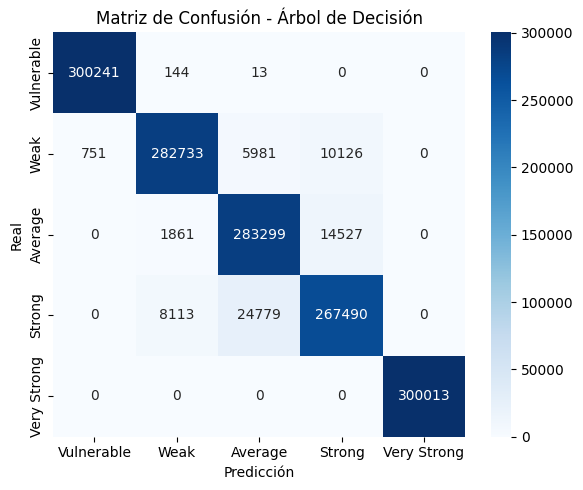

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Vulnerable','Weak', 'Average', 'Strong', 'Very Strong'],
            yticklabels=['Vulnerable','Weak', 'Average', 'Strong', 'Very Strong'])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.tight_layout()
plt.show()

### Métricas globales

In [10]:
acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')
print(f"Accuracy: {acc_dt:.4f}")
print(f"F1 Score ponderado: {f1_dt:.4f}")

Accuracy: 0.9558
F1 Score ponderado: 0.9558


### Guardar Modelo

In [11]:
import joblib
import pickle

def save_model(model, scaler=None, path='decision_tree_model.pkl', scaler_path='scaler.pkl'):
    # Guardar el modelo
    joblib.dump(model, path)
    print(f"Modelo guardado en {path}")

    # Guardar scaler si se usa
    if scaler is not None:
        with open(scaler_path, 'wb') as f:
            pickle.dump(scaler, f)
        print(f"Scaler guardado en {scaler_path}")

save_model(dt_model)

Modelo guardado en decision_tree_model.pkl


### Cargar Modelo

In [12]:
def load_model(path='decision_tree_model.pkl', scaler_path='scaler.pkl'):
    # Cargar el modelo
    model = joblib.load(path)
    print(f"Modelo cargado desde {path}")
    
    # Cargar scaler si existe
    try:
        with open(scaler_path, 'rb') as f:
            scaler = pickle.load(f)
        print(f"Scaler cargado desde {scaler_path}")
    except FileNotFoundError:
        scaler = None
        print("Scaler no encontrado (opcional).")
    
    return model, scaler

model, _ = load_model()

Modelo cargado desde decision_tree_model.pkl
Scaler no encontrado (opcional).


### Pruebas unitarias

In [14]:
import numpy as np

def analyze_password_tree(password, model, scaler=None):
    features = extract_features(password)
    features = np.array(features).reshape(1, -1)

    if scaler:
        features = scaler.transform(features)

    prediction = model.predict(features)[0]

    labels = ['Vulnerable','Débil', 'Media', 'Fuerte', 'Muy fuerte']
    print(password)
    if prediction < len(labels):
        print(f"Nivel de seguridad de la contraseña: {labels[prediction]} ({prediction})")
    else:
        print(f"Nivel de seguridad: Clase desconocida ({prediction})")

pw = input("Ingresa una contraseña: ")
analyze_password_tree(pw, model)

68s4dfsd
Nivel de seguridad de la contraseña: Débil (1)
